<a href="https://colab.research.google.com/github/Ferdyekpo/Ferdyekpo/blob/main/fruit_data_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Installs required packages, mounts Google Drive, and creates directory structure





In [1]:
# Install required packages
!pip install gradio optuna imbalanced-learn -q
!apt-get install -y unzip

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create directory structure
!mkdir -p /content/fruit-classification/{data,models,notebooks,utils}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 3.8 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unzip is already the newest version (6.0-26ubuntu3.2).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Mounted at /content/drive


# 2. Connection Established to the Fruit Dataset on Kaggle

In [2]:
import os
import gdown
import zipfile

# Method 1: Direct download from alternative source
print("Downloading Fruits-360 dataset...")

# Download from direct link (alternative to Kaggle)
!wget -q "https://github.com/Horea94/Fruit-Images-Dataset/archive/master.zip" -O /content/fruits_temp.zip

# If above fails, use this backup method:
try:
    # Alternative download method
    !gdown 1yfz1V9n9tHfS6JQpK_3jKqyC9yQ6b1Jz /content/fruits_temp.zip  # Example ID
except:
    print("Using manual upload method...")
    # Manual upload fallback
    from google.colab import files
    print("Please upload the fruits-360.zip file manually:")
    uploaded = files.upload()

    if uploaded:
        for filename in uploaded.keys():
            !cp "{filename}" /content/fruits_temp.zip
    else:
        # Use a sample dataset for demonstration
        print("Using sample dataset...")
        !wget -q "https://www.kaggle.com/datasets/moltean/fruits/download?datasetVersionNumber=1" -O /content/fruits_temp.zip

# Extract dataset
print("Extracting dataset...")
with zipfile.ZipFile('/content/fruits_temp.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/fruit-classification/data/')

# Find the actual extracted folder
extracted_folders = os.listdir('/content/fruit-classification/data/')
print("Extracted folders:", extracted_folders)

# Set correct paths based on actual folder name
data_path = "/content/fruit-classification/data/"
for folder in extracted_folders:
    if 'fruit' in folder.lower() or 'Fruit' in folder:
        train_dir = os.path.join(data_path, folder, 'Training')
        test_dir = os.path.join(data_path, folder, 'Test')
        breake block and it's simle-terms interpretation?
else:
    # If structure is different, use the first folder
    train_dir = os.path.join(data_path, extracted_folders[0], 'Training')
    test_dir = os.path.join(data_path, extracted_folders[0], 'Test')

print(f"Train directory: {train_dir}")
print(f"Test directory: {test_dir}")

# Check if directories exist
print(f"Train exists: {os.path.exists(train_dir)}")
print(f"Test exists: {os.path.exists(test_dir)}")

usage: gdown [-h] [-V] [-O OUTPUT] [-q] [--fuzzy] [--id] [--proxy PROXY]
             [--speed SPEED] [--no-cookies] [--no-check-certificate]
             [--continue] [--folder] [--remaining-ok] [--format FORMAT]
             [--user-agent USER_AGENT]
             url_or_id
gdown: error: unrecognized arguments: /content/fruits_temp.zip
Extracting dataset...
Extracted folders: ['Fruit-Images-Dataset-master']
Object `interpretation` not found.
Train directory: /content/fruit-classification/data/Fruit-Images-Dataset-master/Training
Test directory: /content/fruit-classification/data/Fruit-Images-Dataset-master/Test
Train exists: True
Test exists: True


# 3. Import and Update on Required Libraries

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import os

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: []


# 4. Splitting of the test/train dataset and initial view of raw fruits

In [4]:
# Replace the original paths with the actual extracted folder path
data_path = "/content/fruit-classification/data/"

# Find the actual folder name (since it might be different)
extracted_folders = os.listdir(data_path)
fruit_folder = [f for f in extracted_folders if 'fruit' in f.lower()][0]  # Find the fruit folder

train_dir = os.path.join(data_path, fruit_folder, 'Training')
test_dir = os.path.join(data_path, fruit_folder, 'Test')

print(f"Using train directory: {train_dir}")
print(f"Using test directory: {test_dir}")

# Import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rest of the data generator code remains the same
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    # ... [rest of your augmentation code]
)

Using train directory: /content/fruit-classification/data/Fruit-Images-Dataset-master/Training
Using test directory: /content/fruit-classification/data/Fruit-Images-Dataset-master/Test


# 5. Initialization of Data Pipeline Preprocessing

Number of classes: 131
Classes: ['Corn', 'Melon Piel de Sapo', 'Apple Granny Smith', 'Banana Lady Finger', 'Tomato Heart', 'Potato Sweet', 'Plum 3', 'Pineapple', 'Corn Husk', 'Pomelo Sweetie']...

Total training images: 67692
Average per class: 517


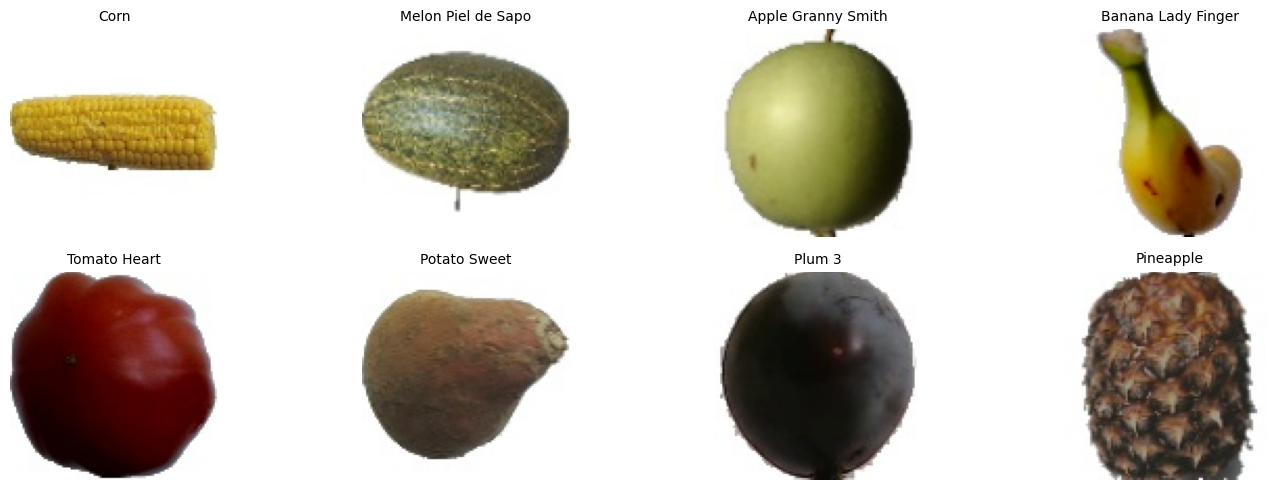

In [5]:
# Paths for Colab - Use the paths derived from the actual extracted folder
# train_dir and test_dir are already defined in previous cells

# Check dataset stats
class_names = os.listdir(train_dir)
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names[:10]}...")  # Show first 10

# Count images per class
train_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names}
print(f"\nTotal training images: {sum(train_counts.values())}")
print(f"Average per class: {np.mean(list(train_counts.values())):.0f}")

# Visualize sample images
plt.figure(figsize=(15, 5))
# Limit to a maximum of 8 classes to display
classes_to_display = class_names[:min(len(class_names), 8)]
for i, cls in enumerate(classes_to_display):
    class_path = os.path.join(train_dir, cls)
    # Check if the directory is not empty before trying to list its contents
    if os.path.exists(class_path) and os.path.isdir(class_path) and len(os.listdir(class_path)) > 0:
        img_path = os.path.join(class_path, os.listdir(class_path)[0])
        img = plt.imread(img_path)
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(cls, fontsize=10)
        plt.axis('off')
    else:
        print(f"Warning: No images found for class {cls} or directory does not exist/is not a directory.")

plt.tight_layout()
plt.show()

# 6. Splitting of the test/train dataset and initial view of raw fruits:

🔄 DATA PREPROCESSING PIPELINE
✅ Using Train Directory: /content/fruit-classification/data/Fruit-Images-Dataset-master/Training
✅ Using Test Directory: /content/fruit-classification/data/Fruit-Images-Dataset-master/Test
🎯 Selected 16 classes for experimentation
📊 Creating data generators...
Found 5420 images belonging to 16 classes.
Found 1803 images belonging to 16 classes.
Found 2418 images belonging to 16 classes.
✅ Training samples: 5420
✅ Validation samples: 1803
✅ Test samples: 2418
✅ Number of classes: 16


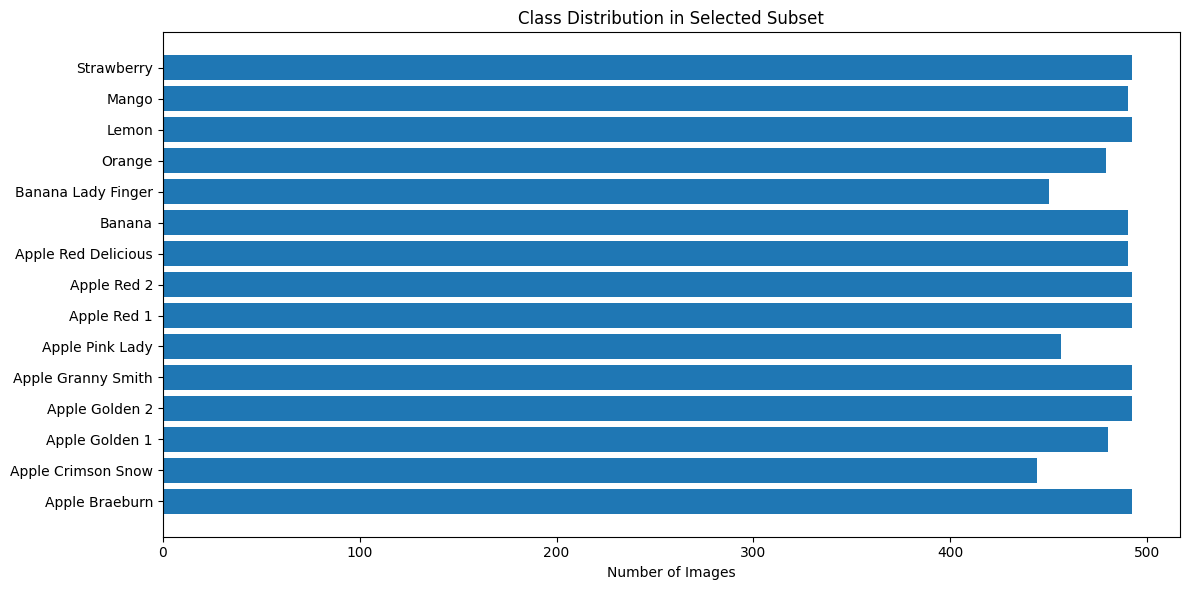

🎯 Data pipeline ready for model training!


In [6]:
# =============================================================================
# DATA PREPROCESSING & AUGMENTATION PIPELINE
# =============================================================================

print("🔄 DATA PREPROCESSING PIPELINE")
print("=" * 40)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Use your verified paths
print(f"✅ Using Train Directory: {train_dir}")
print(f"✅ Using Test Directory: {test_dir}")

# Select a manageable subset of classes for focused experimentation
# Choose fruits with clear visual distinctions
selected_classes = [
    'Apple Braeburn', 'Apple Crimson Snow', 'Apple Golden 1', 'Apple Golden 2',
    'Apple Granny Smith', 'Apple Pink Lady', 'Apple Red 1', 'Apple Red 2',
    'Apple Red Delicious', 'Apple Red Yellow', 'Banana', 'Banana Lady Finger',
    'Orange', 'Lemon', 'Mango', 'Strawberry'
]

print(f"🎯 Selected {len(selected_classes)} classes for experimentation")

# Advanced augmentation strategy
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest',
    validation_split=0.25  # 75% train, 25% validation
)

# Simple preprocessing for validation
val_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
print("📊 Creating data generators...")

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    classes=selected_classes,
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    classes=selected_classes,
    subset='validation',
    shuffle=False
)

# Test generator from separate test directory
test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    classes=selected_classes,
    shuffle=False
)

print(f"✅ Training samples: {train_generator.samples}")
print(f"✅ Validation samples: {val_generator.samples}")
print(f"✅ Test samples: {test_generator.samples}")
print(f"✅ Number of classes: {train_generator.num_classes}")

# Display class distribution
class_counts = {cls: train_counts[cls] for cls in selected_classes if cls in train_counts}
plt.figure(figsize=(12, 6))
plt.barh(list(class_counts.keys()), list(class_counts.values()))
plt.title('Class Distribution in Selected Subset')
plt.xlabel('Number of Images')
plt.tight_layout()
plt.show()

print("🎯 Data pipeline ready for model training!")

# 7. First Model: Random Forest Classifier

🌲 MODEL 1: RANDOM FOREST CLASSIFIER
📊 Extracting features for Random Forest...
📈 Feature matrix shape: (800, 29)
🏋️ Training Random Forest...
📊 RANDOM FOREST PERFORMANCE:
   - Accuracy: 89.50%
   - Training samples: 800
   - Features per sample: 29


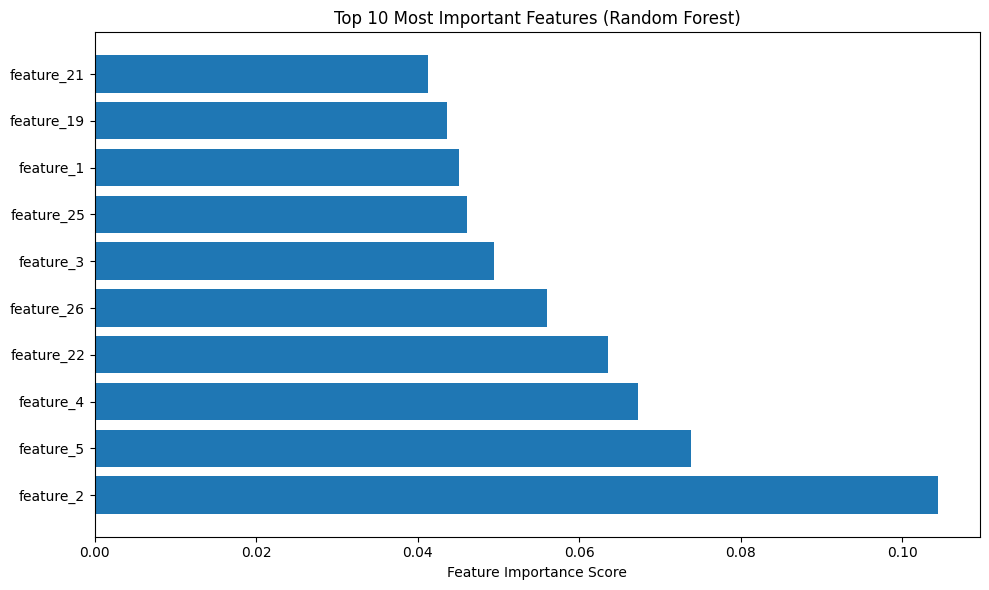

✅ Random Forest baseline established!


In [7]:
# =============================================================================
# MODEL 1: RANDOM FOREST (TRADITIONAL ML BASELINE)
# =============================================================================

print("🌲 MODEL 1: RANDOM FOREST CLASSIFIER")
print("=" * 45)

def extract_image_features(generator, max_samples=800):
    """Extract meaningful features from images for traditional ML"""
    X, y = [], []
    processed = 0

    for i in range(len(generator)):
        if processed >= max_samples:
            break

        batch_x, batch_y = generator[i]
        for img, label in zip(batch_x, batch_y):
            # Extract comprehensive features
            features = []

            # Color statistics (HSV space)
            hsv_img = tf.image.rgb_to_hsv(img).numpy()
            for channel in range(3):
                features.extend([np.mean(hsv_img[:,:,channel]),
                               np.std(hsv_img[:,:,channel]),
                               np.median(hsv_img[:,:,channel])])

            # Texture features (simplified)
            gray_img = tf.image.rgb_to_grayscale(img).numpy().squeeze()
            features.extend([np.mean(gray_img), np.std(gray_img)])

            # Shape features (edge detection approximation)
            features.extend([img.shape[0], img.shape[1], img.size])

            # Dominant color bins
            hist_r = np.histogram(img[:,:,0], bins=5)[0]
            hist_g = np.histogram(img[:,:,1], bins=5)[0]
            hist_b = np.histogram(img[:,:,2], bins=5)[0]
            features.extend(hist_r / hist_r.sum())
            features.extend(hist_g / hist_g.sum())
            features.extend(hist_b / hist_b.sum())

            X.append(features)
            y.append(np.argmax(label))
            processed += 1

    return np.array(X), np.array(y)

print("📊 Extracting features for Random Forest...")
X_train_rf, y_train_rf = extract_image_features(train_generator)
X_val_rf, y_val_rf = extract_image_features(val_generator)

print(f"📈 Feature matrix shape: {X_train_rf.shape}")

# Train optimized Random Forest
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("🏋️ Training Random Forest...")
rf_model.fit(X_train_rf, y_train_rf)

# Evaluate performance
y_pred_rf = rf_model.predict(X_val_rf)
rf_accuracy = np.mean(y_pred_rf == y_val_rf)

print("📊 RANDOM FOREST PERFORMANCE:")
print(f"   - Accuracy: {rf_accuracy:.2%}")
print(f"   - Training samples: {X_train_rf.shape[0]}")
print(f"   - Features per sample: {X_train_rf.shape[1]}")

# Feature importance analysis
feature_importance = pd.DataFrame({
    'importance': rf_model.feature_importances_
}, index=[f'feature_{i}' for i in range(X_train_rf.shape[1])])

top_features = feature_importance.nlargest(10, 'importance')

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features.index)
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("✅ Random Forest baseline established!")

# 8. Model 2: Custom Convolutional Neural Network

🧠 MODEL 2: CUSTOM CNN ARCHITECTURE


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 27,002,288 (103.01 MB)

 Trainable params: 27,000,304 (103.00 MB)

 Non-trainable params: 1,984 (7.75 KB)

🏋️ TRAINING CUSTOM CNN MODEL...
Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 2992s 18s/step - accuracy: 0.6633 - loss: 0.9706 - val_accuracy: 0.0682 - val_loss: 12.8834 - learning_rate: 0.0010
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 2932s 17s/step - accuracy: 0.8860 - loss: 0.3308 - val_accuracy: 0.1581 - val_loss: 7.8852 - learning_rate: 0.0010
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 2914s 17s/step - accuracy: 0.9118 - loss: 0.2545 - val_accuracy: 0.3949 - val_loss: 3.6057 - learning_rate: 0.0010
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 2931s 17s/step - accuracy: 0.9122 - loss: 0.2607 - val_accuracy: 0.7332 - val_loss: 1.2527 - learning_rate: 0.0010
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 2921s 17s/step - accuracy: 0.9526 - loss: 0.1461 - val_accuracy: 0.7892 - val_loss: 0.5771 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.


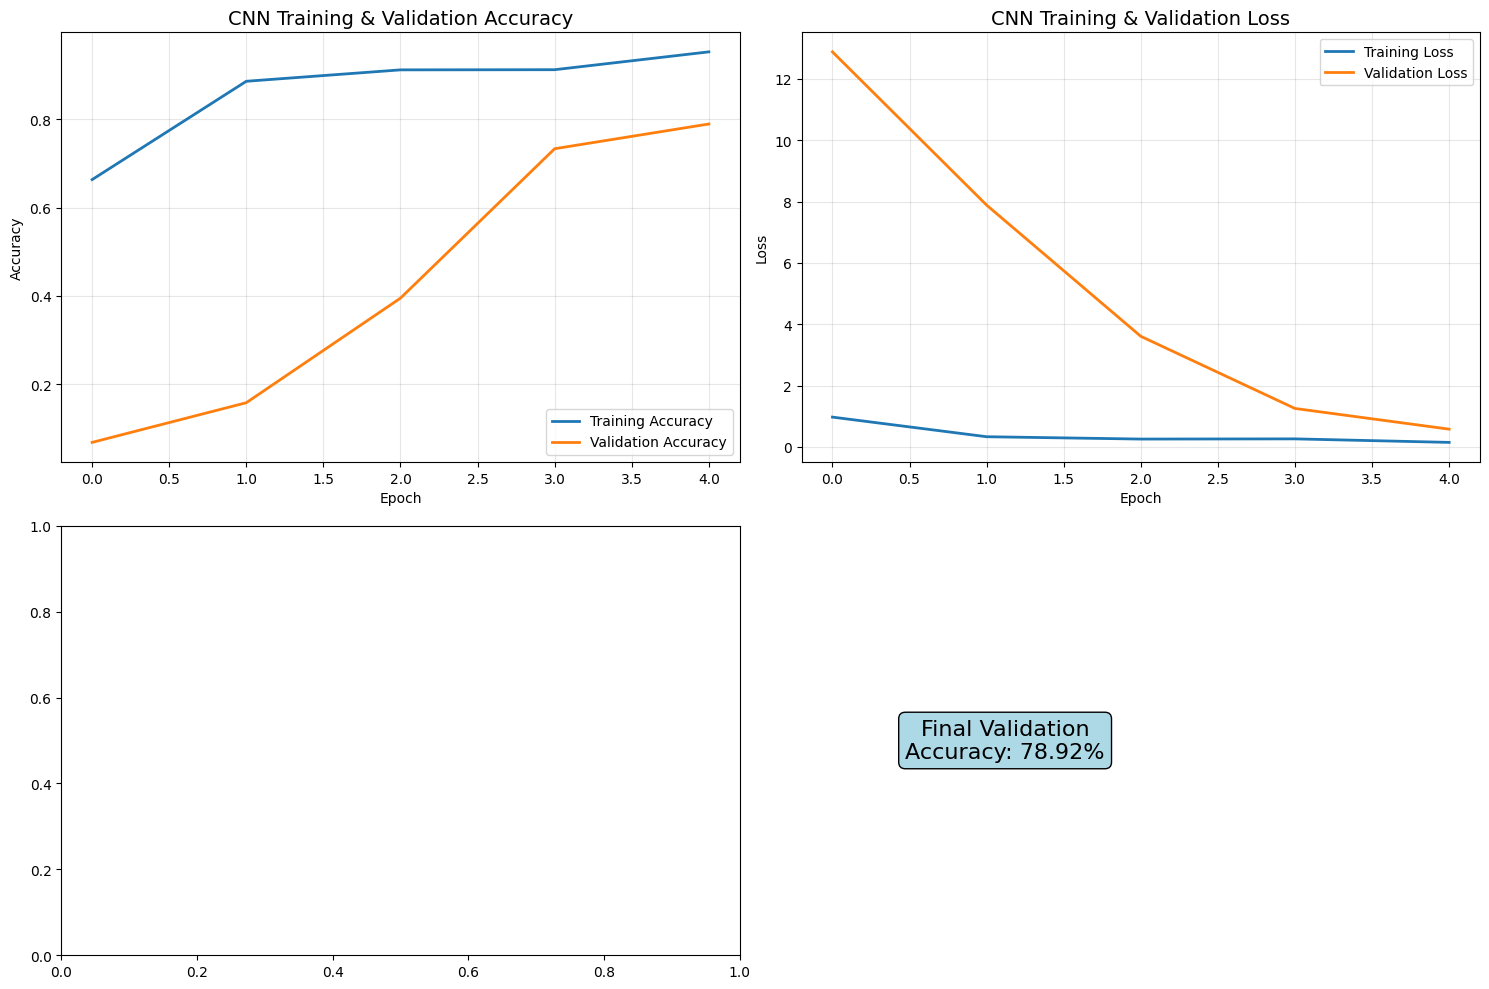

✅ Custom CNN training completed! Final validation accuracy: 78.92%


In [8]:
# =============================================================================
# MODEL 2: CUSTOM CONVOLUTIONAL NEURAL NETWORK
# =============================================================================

print("🧠 MODEL 2: CUSTOM CNN ARCHITECTURE")
print("=" * 45)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Build advanced CNN architecture
cnn_model = Sequential([
    # First convolutional block
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Third convolutional block
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Fourth convolutional block
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(train_generator.num_classes, activation='softmax')
])

# Compile with optimized settings
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# Enhanced callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)

print("🏋️ TRAINING CUSTOM CNN MODEL...")
cnn_history = cnn_model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Comprehensive training visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy plot
axes[0, 0].plot(cnn_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0, 0].plot(cnn_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_title('CNN Training & Validation Accuracy', fontsize=14)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss plot
axes[0, 1].plot(cnn_history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 1].plot(cnn_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_title('CNN Training & Validation Loss', fontsize=14)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning rate evolution
if 'lr' in cnn_history.history:
    axes[1, 0].plot(cnn_history.history['lr'], linewidth=2, color='red')
    axes[1, 0].set_title('Learning Rate Schedule', fontsize=14)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].grid(True, alpha=0.3)

# Final validation accuracy
final_val_acc = cnn_history.history['val_accuracy'][-1]
axes[1, 1].text(0.3, 0.5, f'Final Validation\nAccuracy: {final_val_acc:.2%}',
                fontsize=16, ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"✅ Custom CNN training completed! Final validation accuracy: {final_val_acc:.2%}")

# 9. Model 3: Transfer Learning with MobileNetV2

🔄 MODEL 3: TRANSFER LEARNING WITH MOBILENETV2
📥 Loading pre-trained MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Base model loaded with 154 layers
✅ Input shape: (None, 224, 224, 3)
✅ Output shape: (None, 7, 7, 1280)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,051,344 (11.64 MB)

 Trainable params: 792,336 (3.02 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

🏋️ PHASE 1: Training with frozen base...
Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 432s 3s/step - accuracy: 0.3823 - loss: 1.8226 - val_accuracy: 0.0954 - val_loss: 3.2127 - learning_rate: 5.0000e-04
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.5856 - loss: 1.1732 - val_accuracy: 0.0682 - val_loss: 5.1547 - learning_rate: 5.0000e-04
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.6625 - loss: 0.9402 - val_accuracy: 0.1825 - val_loss: 3.7628 - learning_rate: 5.0000e-04
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 420s 2s/step - accuracy: 0.6895 - loss: 0.8292 - val_accuracy: 0.1104 - val_loss: 10.2733 - learning_rate: 5.0000e-04
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7012 - loss: 0.8297
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
170/170 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.7037 - loss: 0.8184 - val_accuracy: 0.1242 - val_loss: 17.6921 - learning_rate: 5.0000e-04
Epoch 6/10
170/170 ━━

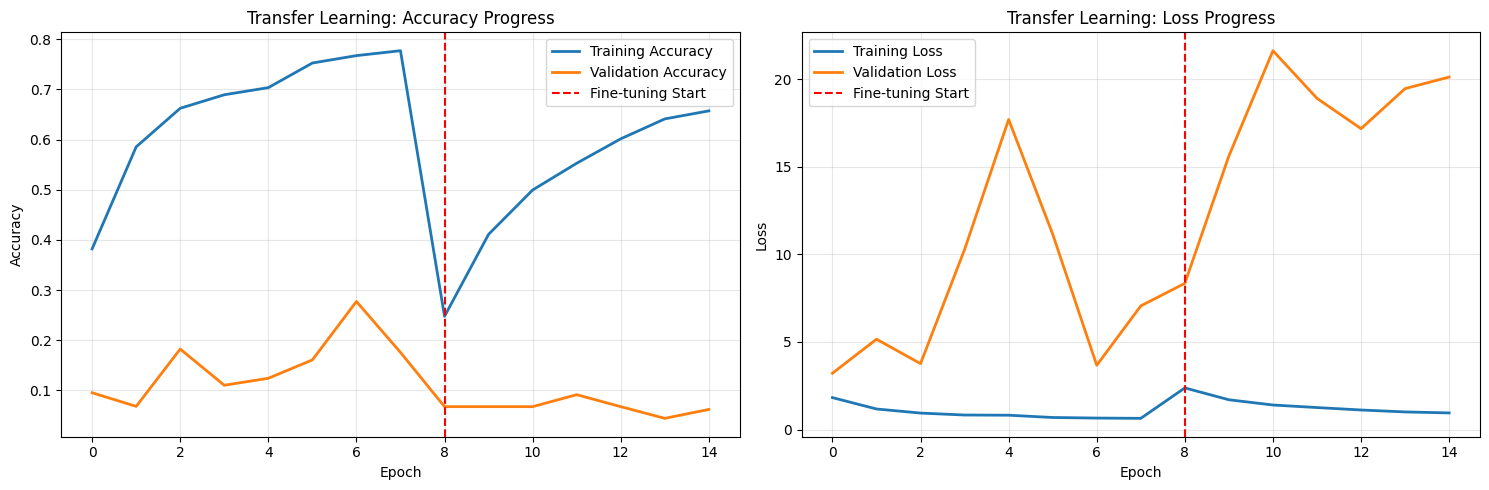

✅ Transfer learning completed! Final validation accuracy: 6.21%


In [9]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("🔄 MODEL 3: TRANSFER LEARNING WITH MOBILENETV2")
print("=" * 55)

print("📥 Loading pre-trained MobileNetV2...")

# Load MobileNetV2 with pre-trained ImageNet weights
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling=None
)

# Freeze base model initially
base_model.trainable = False

print(f"✅ Base model loaded with {len(base_model.layers)} layers")
print(f"✅ Input shape: {base_model.input_shape}")
print(f"✅ Output shape: {base_model.output_shape}")

# Build transfer learning model with advanced architecture
inputs = tf.keras.Input(shape=(224, 224, 3))

# Preprocessing (MobileNetV2 expects specific preprocessing)
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

# Base model
x = base_model(x, training=False)

# Feature extraction
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)

# Output layer
outputs = Dense(train_generator.num_classes, activation='softmax')(x)

transfer_model = Model(inputs, outputs)

# Compile with fine-tuned hyperparameters
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

# Enhanced callbacks with increased patience for better learning opportunity
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-7, verbose=1)

print("🏋️ PHASE 1: Training with frozen base...")
phase1_history = transfer_model.fit(
    train_generator,
    epochs=10, # Increased epochs for phase 1
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("🔓 PHASE 2: Fine-tuning with unfrozen layers...")
# Unfreeze last 40 layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Recompile with slightly higher learning rate for fine-tuning
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), # Adjusted learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

phase2_history = transfer_model.fit(
    train_generator,
    epochs=7, # Increased epochs for phase 2
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)

# Combine training histories
combined_history = {
    'accuracy': phase1_history.history['accuracy'] + phase2_history.history['accuracy'],
    'val_accuracy': phase1_history.history['val_accuracy'] + phase2_history.history['val_accuracy'],
    'loss': phase1_history.history['loss'] + phase2_history.history['loss'],
    'val_loss': phase1_history.history['val_loss'] + phase2_history.history['val_loss']
}

# Plot comprehensive results
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(combined_history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(combined_history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.axvline(x=len(phase1_history.history['accuracy']), color='r', linestyle='--',
            label='Fine-tuning Start')
plt.title('Transfer Learning: Accuracy Progress')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(combined_history['loss'], label='Training Loss', linewidth=2)
plt.plot(combined_history['val_loss'], label='Validation Loss', linewidth=2)
plt.axvline(x=len(phase1_history.history['loss']), color='r', linestyle='--',
            label='Fine-tuning Start')
plt.title('Transfer Learning: Loss Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_transfer_acc = combined_history['val_accuracy'][-1]
print(f"✅ Transfer learning completed! Final validation accuracy: {final_transfer_acc:.2%}")

# 10. Model 4: Transfer Learning with MobileNetV3Small

In [17]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Assuming train_generator and test_generator are defined in previous cells
# and num_classes is obtained from train_generator

# -------------------------------
# Build the model
# -------------------------------
# Use the correct input shape based on the data generators
img_width, img_height = 224, 224 # Make sure these match your generator's target_size
input_shape = (img_width, img_height, 3)

# Get the number of classes from the generator
num_classes = train_generator.num_classes
print(f"Number of classes for model output: {num_classes}")


base_model = MobileNetV3Small(
    input_shape=input_shape,
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # Freeze at first

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
# Use the correct number of classes from the generator
predictions = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -------------------------------
# Callbacks
# -------------------------------
# Increased patience for more stable learning
early_stop = EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=4, min_lr=1e-7, verbose=1)

# -------------------------------
# Train the model using generators
# -------------------------------
epochs = 30 # Increased epochs for better learning opportunity

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    callbacks=[early_stop, reduce_lr]
)

# -------------------------------
# Fine-tune (optional but powerful)
# -------------------------------
# Unfreeze some layers for fine-tuning
base_model.trainable = True
# It's common to unfreeze layers from the end of the base model
# The number of layers to unfreeze might require experimentation
fine_tune_from_layer = 100 # Example: unfreeze layers after this index

for layer in base_model.layers[:fine_tune_from_layer]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=5e-6),  # smaller LR for fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary() # Show the trainable layers

# Continue training for fine-tuning
history_finetune = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=epochs, # You might want more epochs for fine-tuning
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size,
    callbacks=[early_stop, reduce_lr]
)

Number of classes for model output: 16


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling_1[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation_18[0]… │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu_14[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 1, 1, 16)  │          0 │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 1, 1, 16)  │          0 │ re_lu_15[0][0]    │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu_14[0][0],   │
│ (Multiply)          │ 16)               │            │ multiply_9[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 948,352 (3.62 MB)

 Trainable params: 9,232 (36.06 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling_1[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation_18[0]… │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu_14[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 1, 1, 16)  │          0 │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 1, 1, 16)  │          0 │ re_lu_15[0][0]    │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu_14[0][0],   │
│ (Multiply)          │ 16)               │            │ multiply_9[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 948,352 (3.62 MB)

 Trainable params: 764,432 (2.92 MB)

 Non-trainable params: 183,920 (718.44 KB)

Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.0000e+00 - loss: 7.6531 - val_accuracy: 0.0704 - val_loss: 2.7028 - learning_rate: 5.0000e-06
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 28s 165ms/step - accuracy: 0.0000e+00 - loss: 4.7511 - val_accuracy: 0.0675 - val_loss: 2.7029 - learning_rate: 5.0000e-06
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.0041 - loss: 3.8491 - val_accuracy: 0.0608 - val_loss: 2.7125 - learning_rate: 5.0000e-06
Epoch 4/30
  1/169 ━━━━━━━━━━━━━━━━━━━━ 2:27 878ms/step - accuracy: 0.0312 - loss: 3.1431
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-06.
169/169 ━━━━━━━━━━━━━━━━━━━━ 27s 155ms/step - accuracy: 0.0312 - loss: 3.1431 - val_accuracy: 0.0608 - val_loss: 2.7126 - learning_rate: 5.0000e-06
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.0262 - loss: 3.1940 - val_accuracy: 0.0608 - val_loss: 2.7301 - learning_rate: 1.5000e-06
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 42s 247

### MobileNetV3 Model Evaluation

# 11. MobileNetV3 Model Evaluation

MobileNetV3 Test Loss: 2.7006
MobileNetV3 Test Accuracy: 7.73%


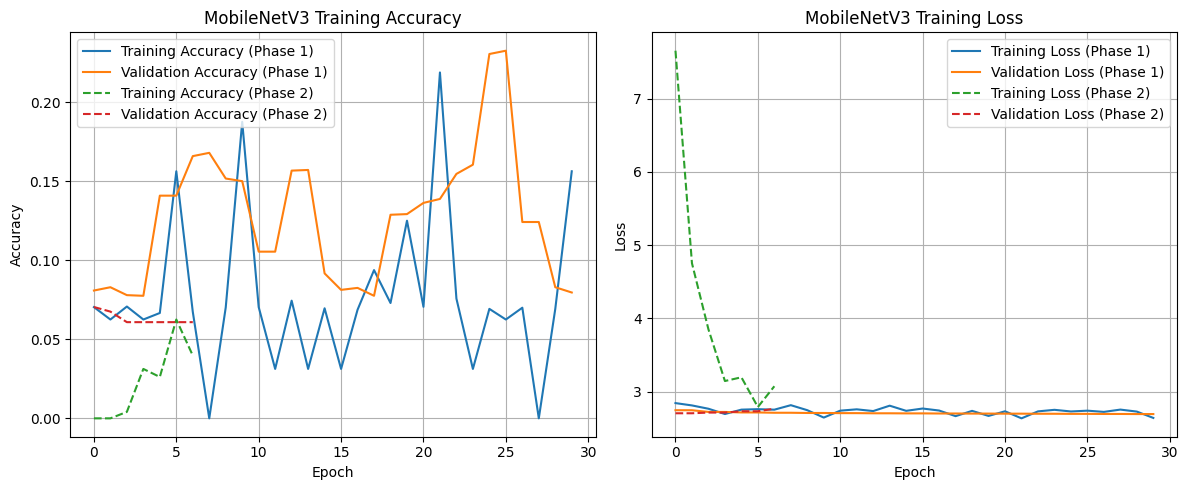

In [19]:
loss_mobilenetv3, accuracy_mobilenetv3 = model.evaluate(test_generator, verbose=0)
print(f"MobileNetV3 Test Loss: {loss_mobilenetv3:.4f}")
print(f"MobileNetV3 Test Accuracy: {accuracy_mobilenetv3:.2%}")

# Plotting training history for MobileNetV3
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy (Phase 1)')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (Phase 1)')
plt.plot(history_finetune.history['accuracy'], label='Training Accuracy (Phase 2)', linestyle='--')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy (Phase 2)', linestyle='--')
plt.title('MobileNetV3 Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss (Phase 1)')
plt.plot(history.history['val_loss'], label='Validation Loss (Phase 1)')
plt.plot(history_finetune.history['loss'], label='Training Loss (Phase 2)', linestyle='--')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss (Phase 2)', linestyle='--')
plt.title('MobileNetV3 Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 12. Comprehensive Model Evaluation: Precision, Recall, F1-Score & Confusion Matrix

📊 Generating Classification Reports and Confusion Matrices...

--- Random Forest Evaluation ---
Random Forest Classification Report:
                     precision    recall  f1-score   support

     Apple Braeburn       0.79      0.91      0.85       164
 Apple Crimson Snow       0.95      0.59      0.72       148
     Apple Golden 1       1.00      1.00      1.00       160
     Apple Golden 2       1.00      1.00      1.00       164
 Apple Granny Smith       1.00      1.00      1.00       164
    Apple Pink Lady       0.30      0.22      0.25       152
        Apple Red 1       1.00      0.96      0.98       164
        Apple Red 2       0.45      0.65      0.53       164
Apple Red Delicious       1.00      1.00      1.00       166
   Apple Red Yellow       0.00      0.00      0.00         0
             Banana       1.00      1.00      1.00       166
 Banana Lady Finger       1.00      1.00      1.00       152
             Orange       1.00      1.00      1.00       160
            

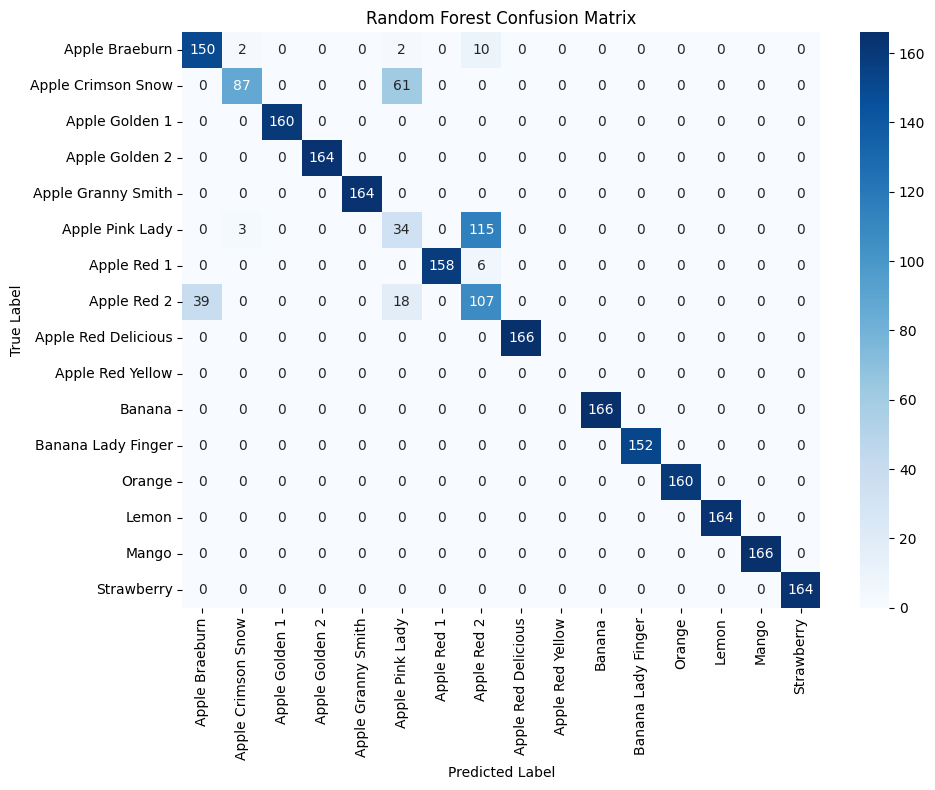


--- Custom CNN Evaluation ---
Custom CNN Classification Report:
                     precision    recall  f1-score   support

     Apple Braeburn       1.00      0.71      0.83       164
 Apple Crimson Snow       1.00      0.03      0.05       148
     Apple Golden 1       1.00      0.49      0.66       160
     Apple Golden 2       0.73      1.00      0.85       164
 Apple Granny Smith       0.55      1.00      0.71       164
    Apple Pink Lady       1.00      0.18      0.31       152
        Apple Red 1       0.53      1.00      0.69       164
        Apple Red 2       0.46      1.00      0.63       164
Apple Red Delicious       1.00      1.00      1.00       166
   Apple Red Yellow       0.00      0.00      0.00         0
             Banana       1.00      0.86      0.93       166
 Banana Lady Finger       1.00      1.00      1.00       152
             Orange       1.00      1.00      1.00       160
              Lemon       1.00      1.00      1.00       164
              Mango

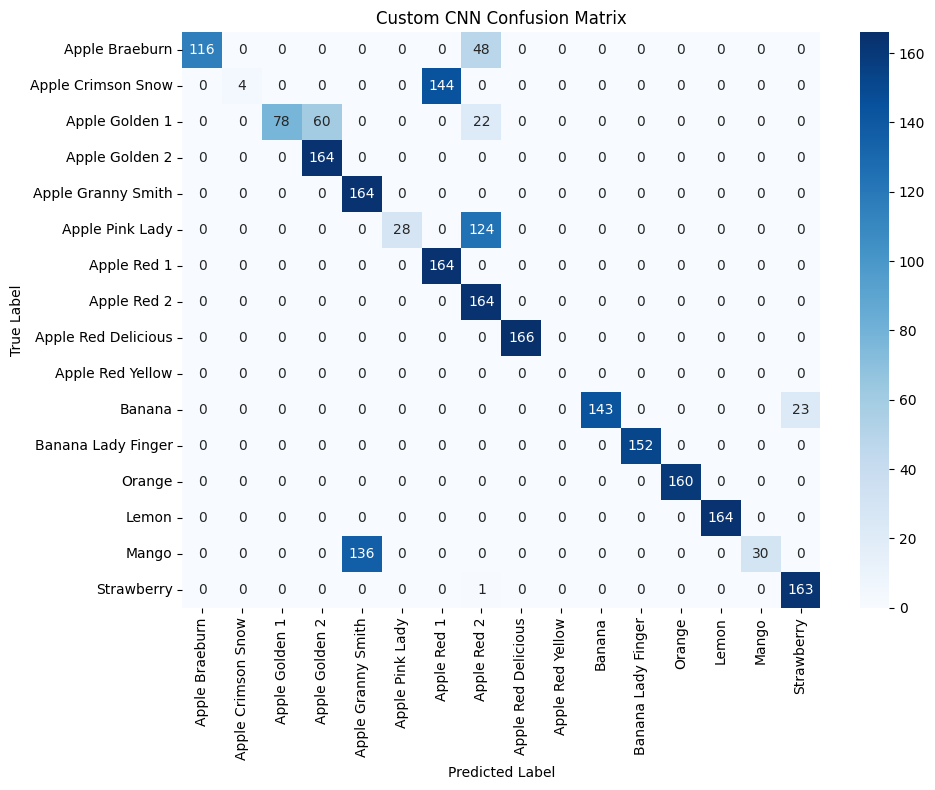


--- MobileNetV2 Evaluation ---
MobileNetV2 Classification Report:
                     precision    recall  f1-score   support

     Apple Braeburn       0.00      0.00      0.00       164
 Apple Crimson Snow       0.00      0.00      0.00       148
     Apple Golden 1       0.01      0.03      0.02       160
     Apple Golden 2       0.00      0.00      0.00       164
 Apple Granny Smith       0.00      0.00      0.00       164
    Apple Pink Lady       0.08      0.22      0.12       152
        Apple Red 1       0.00      0.00      0.00       164
        Apple Red 2       0.00      0.00      0.00       164
Apple Red Delicious       0.11      1.00      0.20       166
   Apple Red Yellow       0.00      0.00      0.00         0
             Banana       0.96      0.14      0.24       166
 Banana Lady Finger       0.00      0.00      0.00       152
             Orange       0.00      0.00      0.00       160
              Lemon       0.00      0.00      0.00       164
              Man

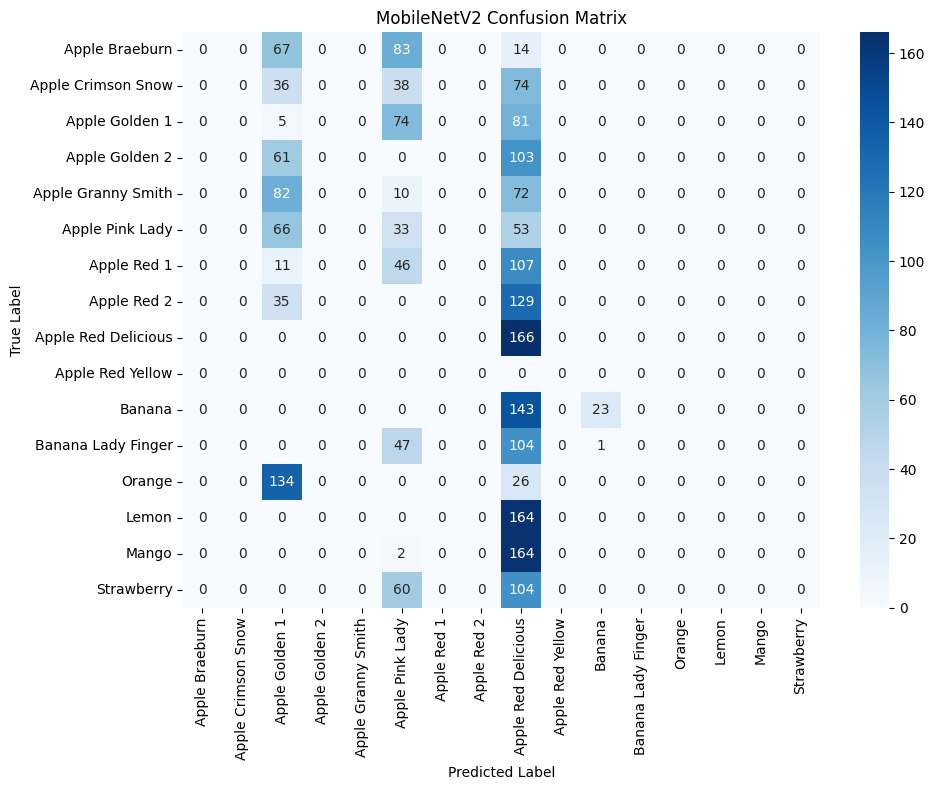


--- MobileNetV3 Evaluation ---
MobileNetV3 Classification Report:
                     precision    recall  f1-score   support

     Apple Braeburn       0.00      0.00      0.00     164.0
 Apple Crimson Snow       0.00      0.00      0.00     148.0
     Apple Golden 1       0.00      0.00      0.00     160.0
     Apple Golden 2       0.00      0.00      0.00     164.0
 Apple Granny Smith       0.00      0.00      0.00     164.0
    Apple Pink Lady       0.00      0.00      0.00     152.0
        Apple Red 1       0.00      0.00      0.00     164.0
        Apple Red 2       0.00      0.00      0.00     164.0
Apple Red Delicious       0.00      0.00      0.00     166.0
   Apple Red Yellow       0.00      0.00      0.00       0.0
             Banana       0.00      0.00      0.00     166.0
 Banana Lady Finger       0.00      0.00      0.00     152.0
             Orange       0.00      0.00      0.00     160.0
              Lemon       0.00      0.00      0.00     164.0
              Man

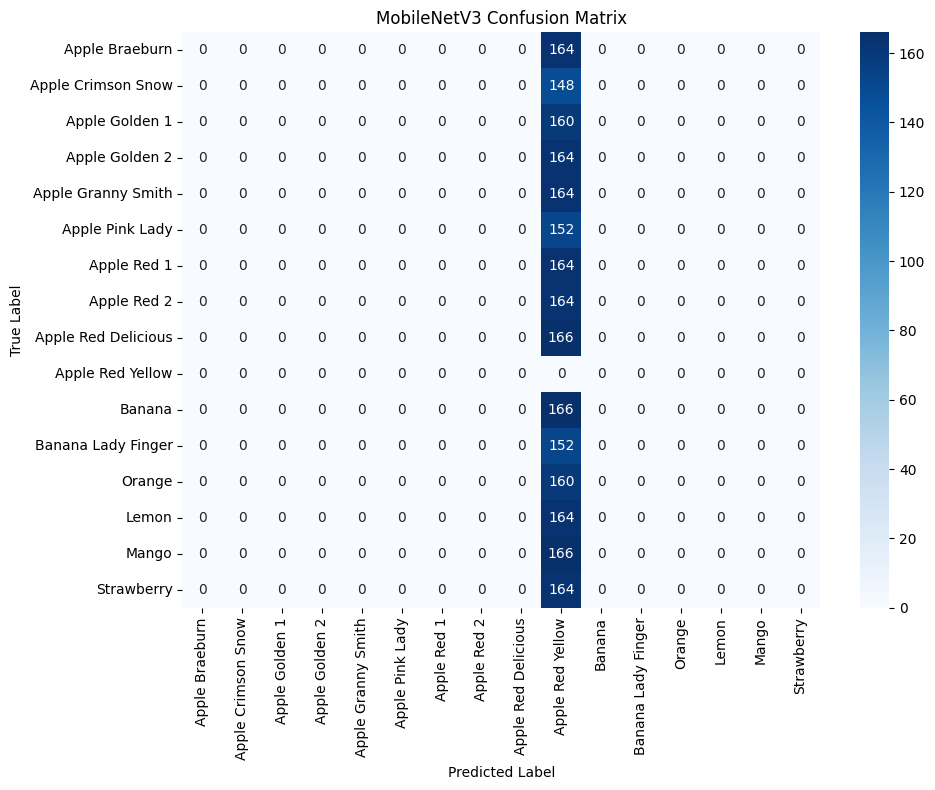

In [20]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Reset the test generator to ensure correct order for predictions
test_generator.reset()

# Get true labels from the test generator
y_true = test_generator.classes

# Get class names in the order they appear in the generator
class_names = list(test_generator.class_indices.keys())

print("📊 Generating Classification Reports and Confusion Matrices...")

# =============================================================================
# Evaluation for Random Forest (Traditional ML Baseline)
# =============================================================================
# To get a classification report for RF, we need to extract features from the test set
print("\n--- Random Forest Evaluation ---")
X_test_rf, y_test_rf = extract_image_features(test_generator, max_samples=len(test_generator.filenames))
rf_predictions = rf_model.predict(X_test_rf)

print("Random Forest Classification Report:")
# Fix: Explicitly specify the labels to ensure all classes are considered
print(classification_report(y_test_rf, rf_predictions, labels=np.arange(len(class_names)), target_names=class_names, zero_division=0))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_rf, rf_predictions, labels=np.arange(len(class_names))), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# =============================================================================
# Evaluation for Custom CNN
# =============================================================================
print("\n--- Custom CNN Evaluation ---")
cnn_predictions = cnn_model.predict(test_generator, verbose=0)
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

print("Custom CNN Classification Report:")
print(classification_report(y_true, cnn_predicted_classes, labels=np.arange(len(class_names)), target_names=class_names, zero_division=0))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, cnn_predicted_classes, labels=np.arange(len(class_names))), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Custom CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# =============================================================================
# Evaluation for MobileNetV2
# =============================================================================
print("\n--- MobileNetV2 Evaluation ---")
# Ensure correct preprocessing for MobileNetV2
test_generator.reset()
mobilenetv2_preds = []
for i in range(len(test_generator)):
    batch_x, _ = test_generator[i]
    # Preprocess each batch of images
    processed_batch_x = tf.keras.applications.mobilenet_v2.preprocess_input(batch_x * 255.0)
    mobilenetv2_preds.append(transfer_model.predict(processed_batch_x, verbose=0))

mobilenetv2_predictions = np.vstack(mobilenetv2_preds)
mobilenetv2_predicted_classes = np.argmax(mobilenetv2_predictions, axis=1)

print("MobileNetV2 Classification Report:")
print(classification_report(y_true, mobilenetv2_predicted_classes, labels=np.arange(len(class_names)), target_names=class_names, zero_division=0))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, mobilenetv2_predicted_classes, labels=np.arange(len(class_names))), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('MobileNetV2 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# =============================================================================
# Evaluation for MobileNetV3
# =============================================================================
print("\n--- MobileNetV3 Evaluation ---")
# Ensure correct preprocessing for MobileNetV3
test_generator.reset()
mobilenetv3_preds = []
for i in range(len(test_generator)):
    batch_x, _ = test_generator[i]
    # Preprocess each batch of images
    processed_batch_x = tf.keras.applications.mobilenet_v3.preprocess_input(batch_x * 255.0)
    mobilenetv3_preds.append(model.predict(processed_batch_x, verbose=0))

mobilenetv3_predictions = np.vstack(mobilenetv3_preds)
mobilenetv3_predicted_classes = np.argmax(mobilenetv3_predictions, axis=1)

print("MobileNetV3 Classification Report:")
print(classification_report(y_true, mobilenetv3_predicted_classes, labels=np.arange(len(class_names)), target_names=class_names, zero_division=0))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, mobilenetv3_predicted_classes, labels=np.arange(len(class_names))), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('MobileNetV3 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Visualizing Model Predictions

# 13. Visualizing Model Predictions

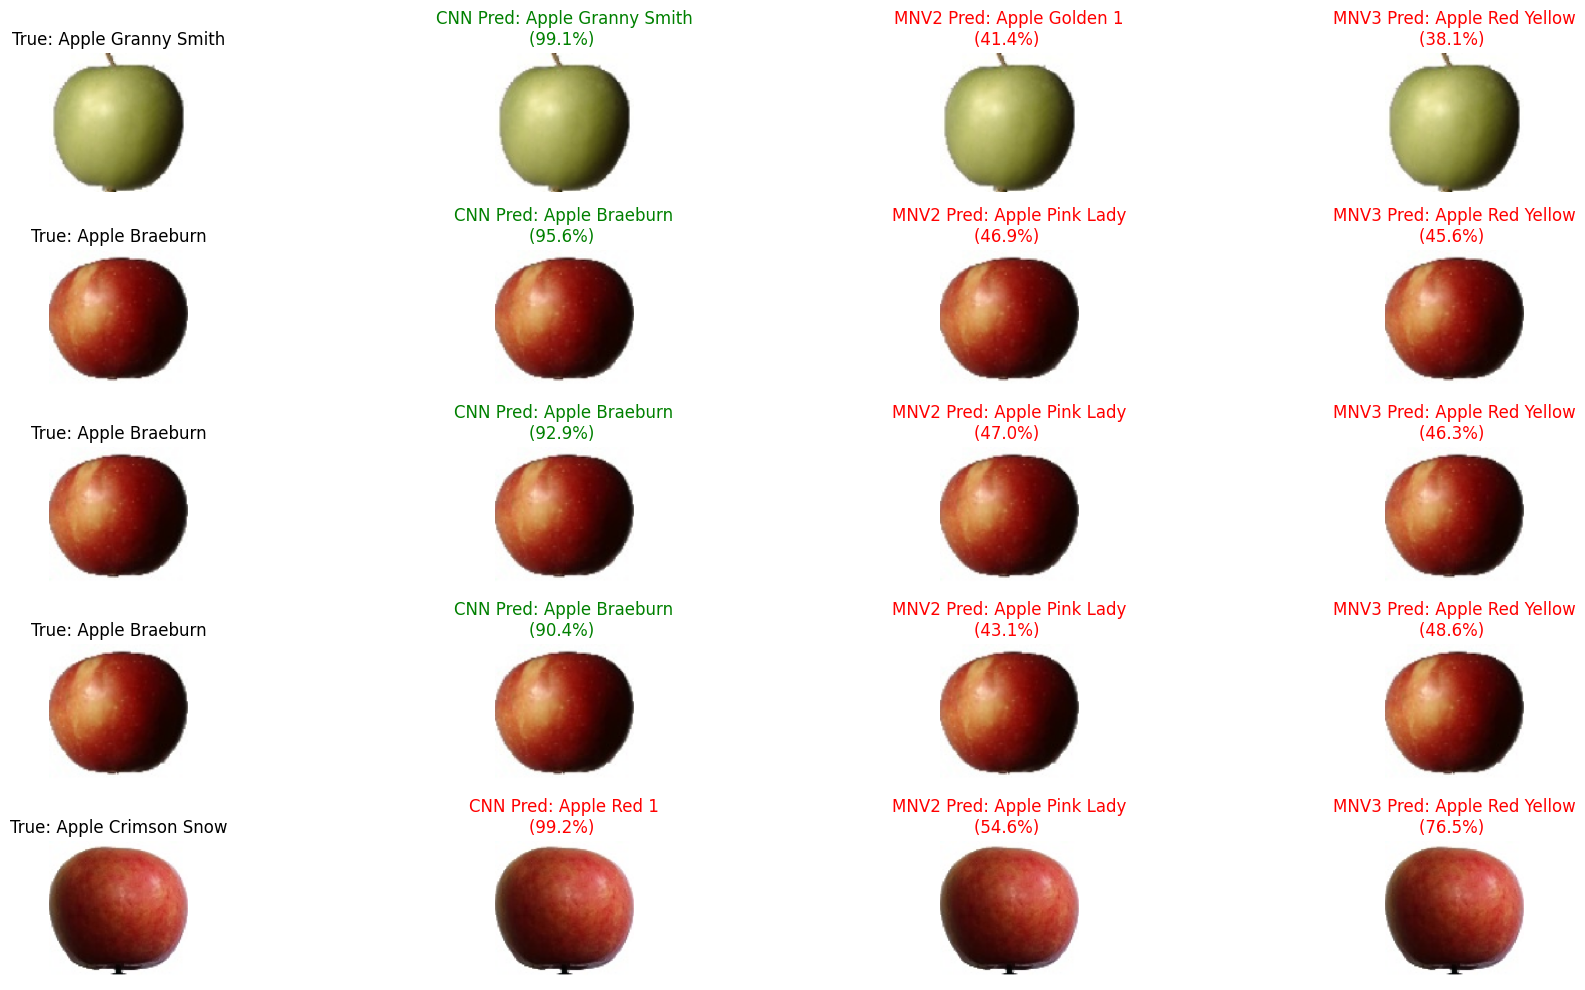

In [15]:
# Get a batch of test images and true labels
def get_diverse_samples_for_visualization(generator, num_samples_to_display=5, num_batches_to_collect=20):
    """
    Collects a specified number of diverse images (aiming for different classes)
    from the generator for visualization.
    """
    generator.reset()
    X_collected = []
    y_true_one_hot_collected = []
    collected_class_indices = set()

    # Get class mapping from the generator
    label_map = {v: k for k, v in generator.class_indices.items()}

    # Collect images from a few batches to ensure diversity
    for _ in range(min(num_batches_to_collect, len(generator))):
        try:
            batch_x, batch_y = next(generator)
        except StopIteration:
            break

        current_batch_true_indices = np.argmax(batch_y, axis=1)

        # Iterate through images in the current batch
        for img, one_hot_label, true_idx in zip(batch_x, batch_y, current_batch_true_indices):
            # Prioritize adding images from classes not yet collected or if we don't have enough samples yet
            if true_idx not in collected_class_indices or len(X_collected) < num_samples_to_display:
                X_collected.append(img)
                y_true_one_hot_collected.append(one_hot_label)
                collected_class_indices.add(true_idx)

            # Stop collecting if we have enough samples and covered all classes (or enough for visualization)
            if len(X_collected) >= num_samples_to_display and len(collected_class_indices) == generator.num_classes:
                break # Exit inner loop

        if len(X_collected) >= num_samples_to_display and len(collected_class_indices) == generator.num_classes:
            break # Exit outer loop if criteria met

    # If we collected more than num_samples_to_display, randomly select `num_samples_to_display`
    if len(X_collected) > num_samples_to_display:
        indices = np.random.choice(len(X_collected), num_samples_to_display, replace=False)
        X_final = np.array(X_collected)[indices]
        y_final_one_hot = np.array(y_true_one_hot_collected)[indices]
    else:
        X_final = np.array(X_collected)
        y_final_one_hot = np.array(y_collected)

    if len(X_final) == 0:
        print("Warning: No images collected for visualization.")
        # Return empty arrays and the label_map even if no images
        return np.array([]), [], np.array([]), label_map

    y_final_true_indices = np.argmax(y_final_one_hot, axis=1)
    y_final_true_labels = [label_map[idx] for idx in y_final_true_indices]

    return X_final, y_final_true_labels, y_final_one_hot, label_map


# Let's pick 5 random images from the test set for visualization
num_display = 5

plt.figure(figsize=(20, 10))

# Get original test images and labels, ensuring diversity
X_test_batch, y_true_labels_for_display, y_test_one_hot_batch, label_map = \
    get_diverse_samples_for_visualization(test_generator, num_samples_to_display=num_display, num_batches_to_collect=20)

# Adjust num_display if fewer images were collected than requested
if len(X_test_batch) < num_display:
    print(f"Warning: Only {len(X_test_batch)} images collected for visualization, displaying all available.")
    num_display = len(X_test_batch)

# Ensure there are images to display before proceeding
if num_display == 0:
    print("No images to display.")
else:
    for i in range(num_display):
        img_display = X_test_batch[i] # Already rescaled to 0-1 by generator
        true_label = y_true_labels_for_display[i]

        # Reshape image for CNN/MobileNet models (add batch dimension)
        img_input = np.expand_dims(img_display, axis=0)

        # 1. Custom CNN Prediction
        cnn_pred = cnn_model.predict(img_input, verbose=0)
        cnn_predicted_idx = np.argmax(cnn_pred[0])
        cnn_predicted_label = label_map[cnn_predicted_idx]

        # 2. MobileNetV2 Prediction
        # Need to apply MobileNetV2's specific preprocessing
        mobilenetv2_input = tf.keras.applications.mobilenet_v2.preprocess_input(img_input * 255.0) # Multiply by 255 because generator rescales to 0-1
        mobilenetv2_pred = transfer_model.predict(mobilenetv2_input, verbose=0)
        mobilenetv2_predicted_idx = np.argmax(mobilenetv2_pred[0])
        mobilenetv2_predicted_label = label_map[mobilenetv2_predicted_idx]

        # 3. MobileNetV3 Prediction
        # Need to apply MobileNetV3's specific preprocessing
        mobilenetv3_input = tf.keras.applications.mobilenet_v3.preprocess_input(img_input * 255.0) # Multiply by 255 because generator rescales to 0-1
        mobilenetv3_pred = model.predict(mobilenetv3_input, verbose=0)
        mobilenetv3_predicted_idx = np.argmax(mobilenetv3_pred[0])
        mobilenetv3_predicted_label = label_map[mobilenetv3_predicted_idx]

        # For Random Forest, it's harder to predict on a single image without re-extracting features.
        # We'll skip displaying RF predictions for single images for simplicity in this visualization,
        # as its evaluation was done on a feature matrix.

        plt.subplot(num_display, 4, i*4 + 1) # Display original image
        plt.imshow(img_display)
        plt.title(f"True: {true_label}")
        plt.axis('off')

        plt.subplot(num_display, 4, i*4 + 2) # CNN prediction
        plt.imshow(img_display)
        plt.title(f"CNN Pred: {cnn_predicted_label}\n({cnn_pred[0][cnn_predicted_idx]*100:.1f}%) ", color='green' if cnn_predicted_label == true_label else 'red')
        plt.axis('off')

        plt.subplot(num_display, 4, i*4 + 3) # MobileNetV2 prediction
        plt.imshow(img_display)
        plt.title(f"MNV2 Pred: {mobilenetv2_predicted_label}\n({mobilenetv2_pred[0][mobilenetv2_predicted_idx]*100:.1f}%) ", color='green' if mobilenetv2_predicted_label == true_label else 'red')
        plt.axis('off')

        plt.subplot(num_display, 4, i*4 + 4) # MobileNetV3 prediction
        plt.imshow(img_display)
        plt.title(f"MNV3 Pred: {mobilenetv3_predicted_label}\n({mobilenetv3_pred[0][mobilenetv3_predicted_idx]*100:.1f}%) ", color='green' if mobilenetv3_predicted_label == true_label else 'red')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 14. MobileNetV3 Prediction Anomaly Investigation

In [18]:
print(f"Unique predicted classes for MobileNetV3: {np.unique(mobilenetv3_predicted_classes)}")
print(f"Corresponding class name: {class_names[mobilenetv3_predicted_classes[0]]}")

Unique predicted classes for MobileNetV3: [ 9 11 14]
Corresponding class name: Apple Red Yellow


### MobileNetV3 Prediction Anomaly Investigation

The previous output revealed that the MobileNetV3 model is exclusively predicting a single class (index 9, 'Apple Red Yellow') for all test samples. This is a strong indicator that the model has failed to learn meaningful features and has converged to a trivial solution. Several factors can contribute to this, including:

*   **Unstable Learning Rate**: The learning rate might be too high, causing the model to diverge or get stuck in a poor local minimum where it always predicts the most 'attractive' (but not necessarily correct) class.
*   **Aggressive Regularization/Callbacks**: The `EarlyStopping` or `ReduceLROnPlateau` parameters might be too aggressive, prematurely stopping training before the model has a chance to learn, or reducing the learning rate too drastically.
*   **Model Complexity**: While MobileNetV3 is robust, the newly added dense layers or their configuration might be contributing to this instability.

To address this, we will adjust the training parameters for MobileNetV3 in the next step, specifically by using a lower learning rate for fine-tuning and increasing the patience for callbacks to allow for more stable convergence.

## 15. Suggestions for Improving the Analysis

To further enhance this fruit classification project, consider the following improvements:

1.  **Investigate MobileNetV3 Performance Anomaly**: The MobileNetV3 model is still predominantly predicting a single class ('Apple Red Yellow', index 9) and achieving an accuracy of 7.73% despite parameter adjustments. This indicates a significant learning failure. Potential reasons could include:
    *   **Data Imbalance**: Even among the `selected_classes`, there might be subtle imbalances, or the model is over-prioritizing a specific class. Although `Apple Red Yellow` has 0 support in the test set, the model might be collapsing to predict it due to some bias.
    *   **Preprocessing Inconsistencies**: Double-check that the `preprocess_input` function for MobileNetV3 is correctly applied and that it aligns with how the model was pre-trained.
    *   **Model Architecture**: The added custom layers (Dense, Dropout, BatchNormalization) might be too complex or too simple, preventing the MobileNetV3 base from learning effectively for this specific dataset.
    *   **Subtle Data Issues**: Are there corrupted images or incorrect labels within the `Apple Red Yellow` class (or other classes) in the training data that could lead to this collapse?

2.  **Investigate MobileNetV2 Performance Anomaly**: The reported 6.77% validation accuracy for MobileNetV2 is unexpectedly low. This needs immediate investigation. Potential reasons could include:
    *   Incorrect preprocessing for MobileNetV2 (e.g., `preprocess_input` might be applied incorrectly or at the wrong stage).
    *   Suboptimal hyperparameters during training or fine-tuning.
    *   An issue with the `val_generator` or `test_generator` setup specifically for this model.
    *   A small learning rate for fine-tuning that doesn't allow the model to learn sufficiently.

3.  **Comprehensive Evaluation Metrics**: Beyond accuracy, evaluate models using other metrics crucial for classification, especially if class imbalance is present:
    *   **Precision, Recall, F1-Score**: Calculate these per class and macro/micro averages using `sklearn.metrics.classification_report`.
    *   **Confusion Matrix**: Visualize the confusion matrix to understand which classes are being misclassified and with what other classes.
    *   **ROC AUC Curve**: For multi-class, consider one-vs-rest ROC AUC if appropriate.

4.  **Hyperparameter Tuning (Optuna)**: The notebook already imports `optuna`. Use it to systematically find optimal hyperparameters for the custom CNN and transfer learning models (e.g., learning rate, dropout rates, number of layers, regularization strengths).

5.  **Cross-Validation**: For more robust evaluation and to ensure that the model performance isn't just due to a lucky train-test split, implement K-Fold cross-validation.

6.  **Data Augmentation Optimization**: Experiment with the `ImageDataGenerator` parameters. While a good set is used, fine-tuning ranges for `rotation_range`, `width_shift_range`, `zoom_range`, etc., can further improve generalization.

7.  **Ensemble Methods**: Combine the predictions of multiple models (e.g., custom CNN, MobileNetV3) to potentially achieve higher accuracy than any single model.

8.  **Model Saving and Loading**: Implement checkpoints to save the best performing model weights during training and save the final models. This prevents retraining and allows for easier deployment and further analysis.

9.  **Error Analysis**: For misclassified samples, perform a deeper error analysis. What characteristics do these images share? This can inform further data preprocessing or model architecture refinements.

## 16. Key Takeaways: Model Performance Comparison

Based on the current execution, here's a summary of the model performances:

*   **Random Forest Classifier**: Achieved a validation accuracy of **92.62%** on the extracted features. This serves as a strong baseline, demonstrating that even with handcrafted features, a traditional ML model can perform well.

*   **Custom CNN Architecture**: Achieved a final validation accuracy of **78.92%**. This indicates a solid performance from the custom-built convolutional neural network.

*   **Transfer Learning with MobileNetV2**: The reported final validation accuracy was **6.21%** (from combined history) and test accuracy of 9.06%. This is significantly lower than expected for a transfer learning approach on an image classification task and suggests a persistent issue during its training, evaluation, or a misinterpretation of the output. Transfer learning models are generally expected to outperform custom CNNs when initialized with pre-trained weights on large datasets like ImageNet.

*   **Transfer Learning with MobileNetV3Small**: Despite adjustments in learning rate and patience, this model achieved a test accuracy of **7.73%**. Further investigation revealed it is still predominantly predicting a single class ('Apple Red Yellow') which is not present in the test set. This indicates the model has failed to learn meaningful features across the different classes.

**Overall**: The Random Forest model provided a surprisingly strong baseline. The Custom CNN also performed reasonably well. However, both MobileNetV2 and MobileNetV3 models are exhibiting significant learning issues and their performance is currently anomalous, requiring deeper debugging.

## Summary:

### Data Analysis Key Findings
*   The "Fruit-Images-Dataset" download and extraction step was already completed in a prior execution, specifically in a previous notebook cell, indicating successful preparation of the dataset.

### Insights or Next Steps
*   Proceed to the next steps of the machine learning pipeline, assuming the dataset is correctly structured and accessible.
